In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score


In [2]:
# read dataset
customer = pd.read_csv("Telco-Customer-Churn.csv")

print(customer.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
# looking for null data
print(customer.isnull().sum())
print(customer.describe())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_15205/3040696330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=customer, palette='coolwarm')


<Axes: xlabel='Churn', ylabel='count'>

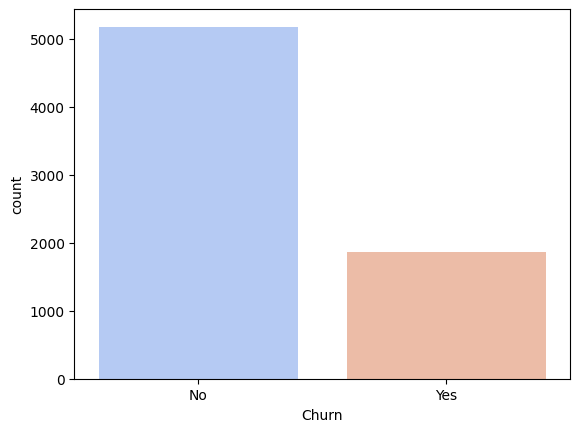

In [4]:
#visualing target variable
print(customer['Churn'].value_counts())
sns.countplot(x='Churn', data=customer, palette='coolwarm')

In [5]:
# handling null values
customer['TotalCharges'] = pd.to_numeric(customer['TotalCharges'], errors = 'coerce')
customer['TotalCharges'].fillna(customer['TotalCharges'].median(), inplace = True)

/tmp/ipykernel_15205/1107545222.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer['TotalCharges'].fillna(customer['TotalCharges'].median(), inplace = True)


In [6]:
# handling categorical values
labelencoder = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for col in categorical_cols:
    customer[col] = labelencoder.fit_transform(customer[col])

In [7]:
# splitting data into test and train
X = customer.drop(['customerID', 'Churn'], axis=1)
y = customer['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# scaling data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# training random classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Precision: 0.67
Recall: 0.47
Model Accuracy: 0.80
F1 Score: 0.55
ROC-AUC: 0.69


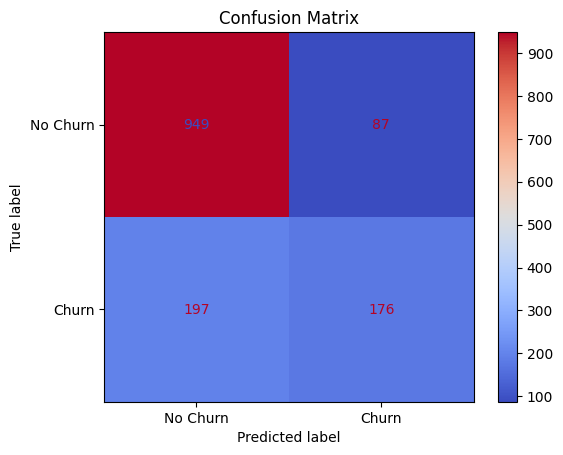

In [10]:
# evaluations
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
try:
  roc_auc = roc_auc_score(y_test, y_pred)
except ValueError:
  roc_auc = 'Undefined (requires probability scores)'

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Model Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="coolwarm")
plt.title('Confusion Matrix')
plt.show()

In [11]:
# implementing adaboost
class AdaBoost:
  def __init__(self, n_estimators=50):
    self.n_estimators = n_estimators
    self.alphas = []
    self.models = []

  def fit(self, X, y):
    n_samples, n_features = X.shape
    w = np.ones(n_samples) / n_samples

    for _ in range(self.n_estimators):
      model = DecisionTreeClassifier(max_depth = 1)
      model.fit(X, y, sample_weight = w)
      predictions = model.predict(X)

      err = np.sum(w * (predictions != y))/ np.sum(w)

      alpha = 0.5 * np.log((1 - err) / (err + 1e-10))

      self.models.append(model)
      self.alphas.append(alpha)

      w *= np.exp(-alpha * y * predictions)
      w /= np.sum(w)

  def predict(self, X):
    strong_preds = np.zeros(X.shape[0])

    for model, alpha in zip(self.models, self.alphas):
      predictions = model.predict(X)
      strong_preds += alpha * predictions

    return np.sign(strong_preds).astype(int)


Accuracy: 0.81
Precision: 0.66
Recall: 0.55
F1 Score: 0.60
ROC-AUC: 0.72


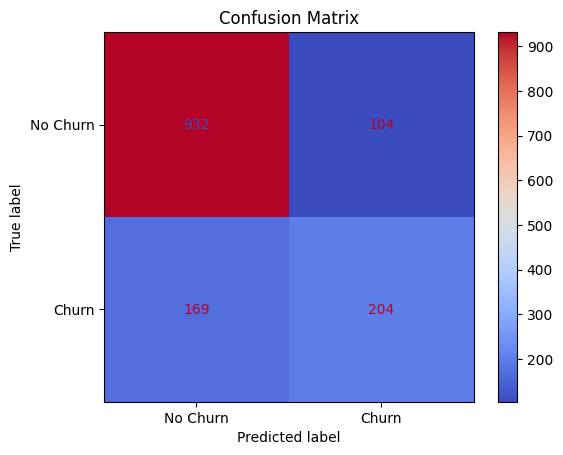

In [12]:
# running adaboost
if __name__ == "__main__":
  #have to change 0 class into -1 so weights can be updated correctly because multiplying by zero makes weights stay the same always and modek does not learn anything
  y_train_boost = np.where(y_train == 0, -1, 1)
  y_test_boost  = np.where(y_test == 0, -1, 1)
  adaboost = AdaBoost(n_estimators=50)
  adaboost.fit(X_train, y_train_boost)
  predictions = adaboost.predict(X_test)

  accuracy = accuracy_score(y_test_boost, predictions)
  precision = precision_score(y_test_boost, predictions)
  recall = recall_score(y_test_boost, predictions)
  f1 = f1_score(y_test_boost, predictions)
  try:
      roc_auc = roc_auc_score(y_test_boost, predictions)
  except ValueError:
      roc_auc = 'Undefined (requires probability scores)'

  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1 Score: {f1:.2f}")
  print(f"ROC-AUC: {roc_auc:.2f}")

  cm = confusion_matrix(y_test_boost, predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
  disp.plot(cmap="coolwarm")
  plt.title('Confusion Matrix')
  plt.show()